In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [4]:
# Load Excel file
file_path = r"cosmetics_dataset.xlsx"

# Read dataset
df = pd.read_excel(file_path)

# Display first 5 rows
print(df.head())

  Product_ID                       Product_Name        Brand   Category  \
0  PROD21130           TRESemme Keratin Shampoo     TRESemme   Haircare   
1  PROD15934  Lakme Hyaluronic Acid Moisturiser        Lakme   Skincare   
2  PROD07506                       Engage Attar       Engage  Fragrance   
3  PROD28526                  Chambor Lip Gloss      Chambor     Makeup   
4  PROD19439  Schwarzkopf Anti-Dandruff Shampoo  Schwarzkopf   Haircare   

   Price  Rating  Number_of_Reviews  Customer_Age Customer_Gender  \
0   1680     NaN              184.0          28.0            Male   
1   2820     3.2              113.0          25.0             NaN   
2   2950     3.5               13.0          20.0          Female   
3    600     2.8              128.0          25.0          Female   
4   2010     4.1              422.0          33.0          Female   

  Purchase_Date  Sales_Quantity  
0    2024-06-07               2  
1    2024-06-01               4  
2    2024-03-13               4 

In [5]:
# Shape of dataset
print("Dataset Shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# Dataset information
print("\nDataset Info:")
print(df.info())

Dataset Shape: (30300, 11)

Columns:
Index(['Product_ID', 'Product_Name', 'Brand', 'Category', 'Price', 'Rating',
       'Number_of_Reviews', 'Customer_Age', 'Customer_Gender', 'Purchase_Date',
       'Sales_Quantity'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30300 entries, 0 to 30299
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Product_ID         30300 non-null  object 
 1   Product_Name       30300 non-null  object 
 2   Brand              30300 non-null  object 
 3   Category           30300 non-null  object 
 4   Price              30300 non-null  int64  
 5   Rating             29702 non-null  float64
 6   Number_of_Reviews  29703 non-null  float64
 7   Customer_Age       29736 non-null  float64
 8   Customer_Gender    29673 non-null  object 
 9   Purchase_Date      30300 non-null  object 
 10  Sales_Quantity     30300 non-null  int64  
dtypes: fl

In [6]:
# Check missing values
print(df.isnull().sum())

Product_ID             0
Product_Name           0
Brand                  0
Category               0
Price                  0
Rating               598
Number_of_Reviews    597
Customer_Age         564
Customer_Gender      627
Purchase_Date          0
Sales_Quantity         0
dtype: int64


In [7]:
# Fill numerical missing values with mean
df['Rating'] = df['Rating'].fillna(df['Rating'].median())
df['Number_of_Reviews'] = df['Number_of_Reviews'].fillna(df['Number_of_Reviews'].median())
df['Customer_Age'] = df['Customer_Age'].fillna(df['Customer_Age'].median())

# Fill categorical missing values with mode
df['Customer_Gender'] = df['Customer_Gender'].fillna(df['Customer_Gender'].mode()[0])

# Check again
print(df.isnull().sum())

Product_ID           0
Product_Name         0
Brand                0
Category             0
Price                0
Rating               0
Number_of_Reviews    0
Customer_Age         0
Customer_Gender      0
Purchase_Date        0
Sales_Quantity       0
dtype: int64


In [8]:
#Statistical Summary
print(df.describe())

              Price        Rating  Number_of_Reviews  Customer_Age  \
count  30300.000000  30300.000000       30300.000000  30300.000000   
mean    2095.782508      3.597172         202.465809     27.369010   
std      935.083755      0.547862         207.194532      7.167677   
min      170.000000      1.500000           1.000000     18.000000   
25%     1390.000000      3.200000          59.000000     21.000000   
50%     1990.000000      3.600000         138.000000     27.000000   
75%     2710.000000      4.000000         277.000000     32.000000   
max     4960.000000      5.000000        2066.000000     57.000000   

       Sales_Quantity  
count    30300.000000  
mean         5.102574  
std          2.244643  
min          1.000000  
25%          3.000000  
50%          5.000000  
75%          7.000000  
max         10.000000  


In [9]:
# Convert date column
df['Purchase_Date'] = pd.to_datetime(df['Purchase_Date'])

# Create new columns
df['Year'] = df['Purchase_Date'].dt.year
df['Month'] = df['Purchase_Date'].dt.month

print(df.head())

  Product_ID                       Product_Name        Brand   Category  \
0  PROD21130           TRESemme Keratin Shampoo     TRESemme   Haircare   
1  PROD15934  Lakme Hyaluronic Acid Moisturiser        Lakme   Skincare   
2  PROD07506                       Engage Attar       Engage  Fragrance   
3  PROD28526                  Chambor Lip Gloss      Chambor     Makeup   
4  PROD19439  Schwarzkopf Anti-Dandruff Shampoo  Schwarzkopf   Haircare   

   Price  Rating  Number_of_Reviews  Customer_Age Customer_Gender  \
0   1680     3.6              184.0          28.0            Male   
1   2820     3.2              113.0          25.0          Female   
2   2950     3.5               13.0          20.0          Female   
3    600     2.8              128.0          25.0          Female   
4   2010     4.1              422.0          33.0          Female   

  Purchase_Date  Sales_Quantity  Year  Month  
0    2024-06-07               2  2024      6  
1    2024-06-01               4  2024   

In [10]:
# Total Sales = Price × Sales Quantity
df['Total_Sales'] = df['Price'] * df['Sales_Quantity']

print(df[['Price', 'Sales_Quantity', 'Total_Sales']].head())

   Price  Sales_Quantity  Total_Sales
0   1680               2         3360
1   2820               4        11280
2   2950               4        11800
3    600               4         2400
4   2010              10        20100


In [11]:
# Monthly sales trend
monthly_sales = df.groupby('Month')['Total_Sales'].sum()

print(monthly_sales)

Month
1     26474510
2     25360660
3     27229890
4     27659360
5     29642190
6     27923400
7     30134050
8     29401210
9     27799380
10    27495270
11    25054420
12    26090950
Name: Total_Sales, dtype: int64


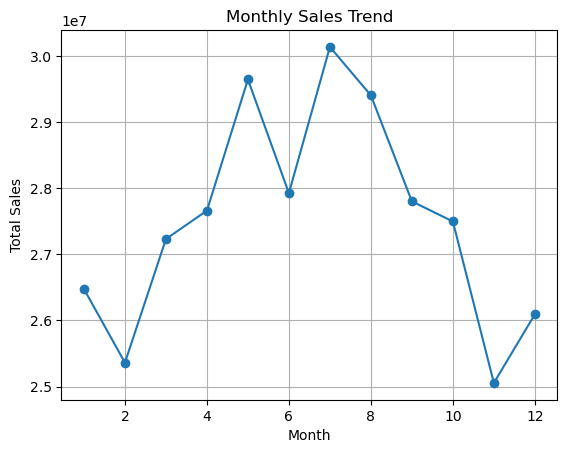

In [13]:
plt.figure()
plt.plot(monthly_sales.index, monthly_sales.values, marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.grid(True)

plt.show()

In [14]:
#Category Wise Sales Analysis
category_sales = df.groupby('Category')['Total_Sales'].sum()

print(category_sales)

Category
Fragrance     54333450
Haircare      41532060
Makeup        88676510
Skincare     145723270
Name: Total_Sales, dtype: int64


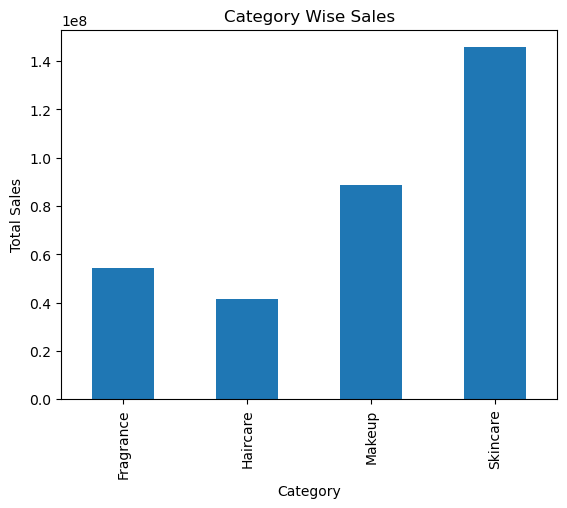

In [15]:
#Plot Category Wise Sales
plt.figure()
category_sales.plot(kind='bar')

plt.title('Category Wise Sales')
plt.xlabel('Category')
plt.ylabel('Total Sales')

plt.show()

In [16]:
#Top Selling Brands
brand_sales = df.groupby('Brand')['Total_Sales'].sum().sort_values(ascending=False)

print(brand_sales.head(10))

Brand
Lakme                22801190
WOW Skin Science     19009810
Biotique             18713700
Mamaearth            17890840
Plum                 15479790
Minimalist           15020360
Lotus Herbals        14935860
Neutrogena           14599770
Olay                 14440590
Forest Essentials    13779700
Name: Total_Sales, dtype: int64


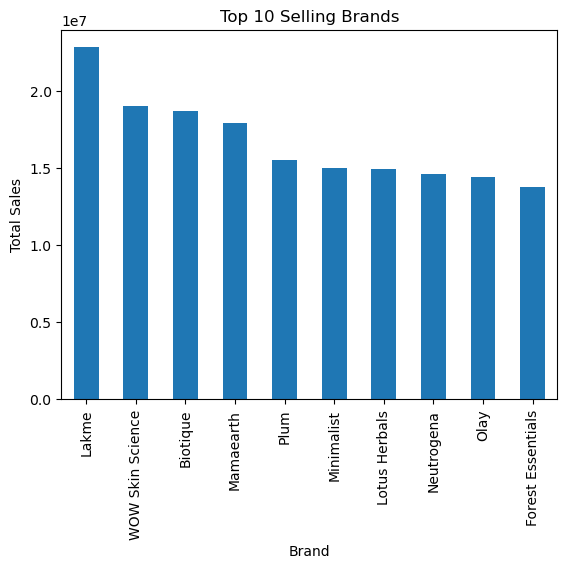

In [17]:
#Plot Top 10 Brands
plt.figure()
brand_sales.head(10).plot(kind='bar')

plt.title('Top 10 Selling Brands')
plt.xlabel('Brand')
plt.ylabel('Total Sales')

plt.show()

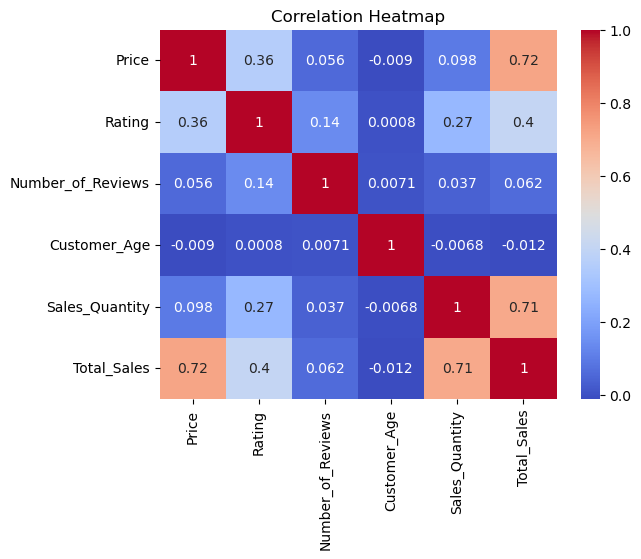

In [22]:
# Select only numerical columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Correlation matrix
correlation_matrix = numeric_df.corr()

#Heatmap for Correlation
plt.figure()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [23]:
#REGRESSION ANALYSIS
# Features
X = df[['Price', 'Rating', 'Number_of_Reviews', 'Customer_Age']]

# Target
y = df['Total_Sales']

In [24]:
#Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [28]:
# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(y_pred[:10])

[ 1829.38693679  6697.94830653  8372.85906141  7815.65989965
 18440.38724067   802.87274957  7454.67585738 22348.69024481
  7693.32819739  5950.36319052]


In [29]:
#REGRESSION METRICS
# MAE
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mae)

# MSE
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

# RMSE
rmse = np.sqrt(mse)
print("Root Mean Squared Error:", rmse)

# R2 Score
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

Mean Absolute Error: 3743.938518488327
Mean Squared Error: 25164115.9083974
Root Mean Squared Error: 5016.384744853349
R2 Score: 0.5207747552338658


In [30]:
#Improving R2 score using more features
# Add more useful features
X = df[[
    'Price',
    'Rating',
    'Number_of_Reviews',
    'Customer_Age',
    'Sales_Quantity',
    'Month'
]]

# Target
y = df['Total_Sales']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# R2 score
r2 = r2_score(y_test, y_pred)

print("Improved R2 Score:", r2)

Improved R2 Score: 0.9165772672976402


In [32]:
# CREATE SALES CATEGORY
# Calculate average sales
average_sales = df['Total_Sales'].mean()

# Create new column
df['Sales_Category'] = np.where(
    df['Total_Sales'] > average_sales,
    'High',
    'Low'
)

# Check column
print(df[['Total_Sales', 'Sales_Category']].head())

   Total_Sales Sales_Category
0         3360            Low
1        11280           High
2        11800           High
3         2400            Low
4        20100           High


In [39]:
# Features
X = df[[
    'Price',
    'Rating',
    'Number_of_Reviews',
    'Customer_Age',
    'Sales_Quantity'
]]

# Target
y = df['Sales_Category']

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train Model
classifier = DecisionTreeClassifier(random_state=42)

classifier.fit(X_train, y_train)

# Prediction
y_pred = classifier.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Score :", accuracy)

Accuracy Score : 1.0


In [38]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix")
print(cm)

# Classification Report
print("\nClassification Report")
print(classification_report(y_test, y_pred))


Confusion Matrix
[[2491    0]
 [   0 3569]]

Classification Report
              precision    recall  f1-score   support

        High       1.00      1.00      1.00      2491
         Low       1.00      1.00      1.00      3569

    accuracy                           1.00      6060
   macro avg       1.00      1.00      1.00      6060
weighted avg       1.00      1.00      1.00      6060



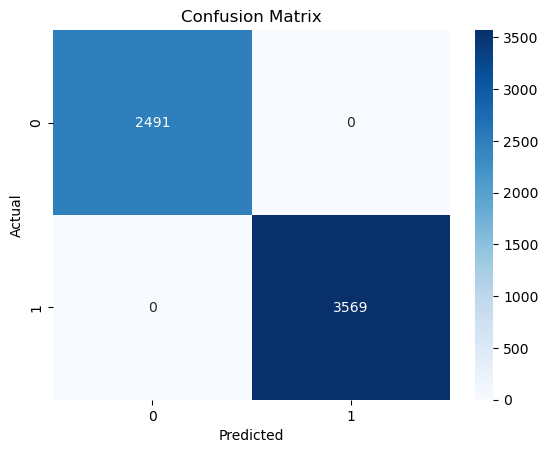

In [40]:
plt.figure()

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()